# Phân tích Cụm Creator TikTok – Comparative Clustering
**Thuật toán:** K-Means · Hierarchical · DBSCAN · Spectral  
**Input:** `model_features_transformed.csv`

## 0. Imports

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import KernelPCA, PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import scipy.cluster.hierarchy as sch

sns.set_theme(style="whitegrid")


## 1. Load dữ liệu · Scaling · KPCA
- **Scaler:** `RobustScaler`  
- **KPCA:** `kernel='rbf'`, gamma tùy chỉnh bên dưới

In [28]:
df_raw = pd.read_csv('pipeline_P6_scaled.csv')
df     = df_raw.drop(columns=['handleName'], errors='ignore')

pca = PCA(n_components=0.95)
X_model = pca.fit_transform(df)
print(f"Số chiều sau PCA: {X_model.shape[1]}")


Số chiều sau PCA: 7


## 2. K-Means

### 2a. Elbow Method – WCSS (k = 1 → 10)

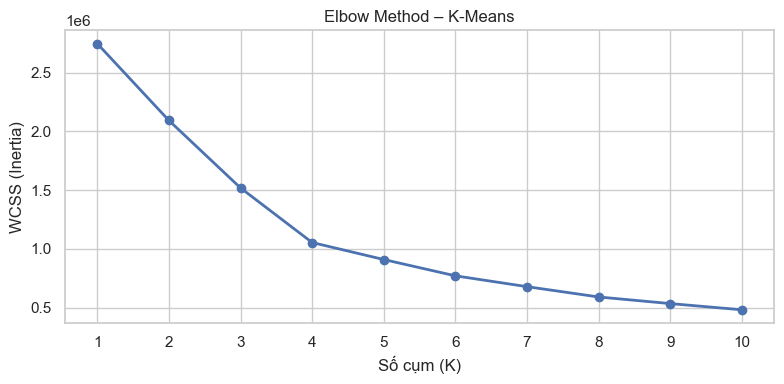

In [29]:
wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_model)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), wcss, marker='o', linewidth=2)
plt.xlabel('Số cụm (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method – K-Means')
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()


### 2b. Silhouette Score (k = 2 → 10) – chọn k có score cao nhất

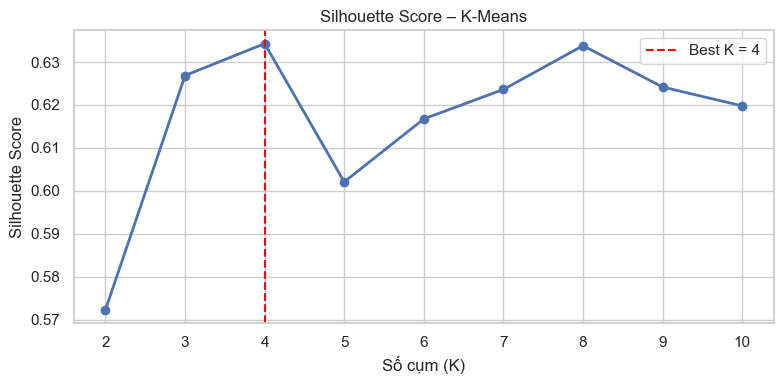

K tối ưu (Silhouette): 4


In [30]:
K_sil = range(2, 11)
sil_km = []
for k in K_sil:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_model)
    sil_km.append(silhouette_score(X_model, labels))

best_k_km = list(K_sil)[int(np.argmax(sil_km))]

plt.figure(figsize=(8, 4))
plt.plot(list(K_sil), sil_km, marker='o', linewidth=2)
plt.axvline(best_k_km, color='red', linestyle='--', label=f'Best K = {best_k_km}')
plt.xlabel('Số cụm (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score – K-Means')
plt.legend()
plt.tight_layout()
plt.show()
print(f"K tối ưu (Silhouette): {best_k_km}")


### 2c. Fit K-Means với k tối ưu

In [31]:
K_KMEANS     = best_k_km   # ← ghi đè thủ công nếu muốn
kmeans       = KMeans(n_clusters=K_KMEANS, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_model)
print(f"K-Means fitted với K = {K_KMEANS}")


K-Means fitted với K = 4


## 3. Hierarchical Clustering (Ward)

### 3a. Dendrogram

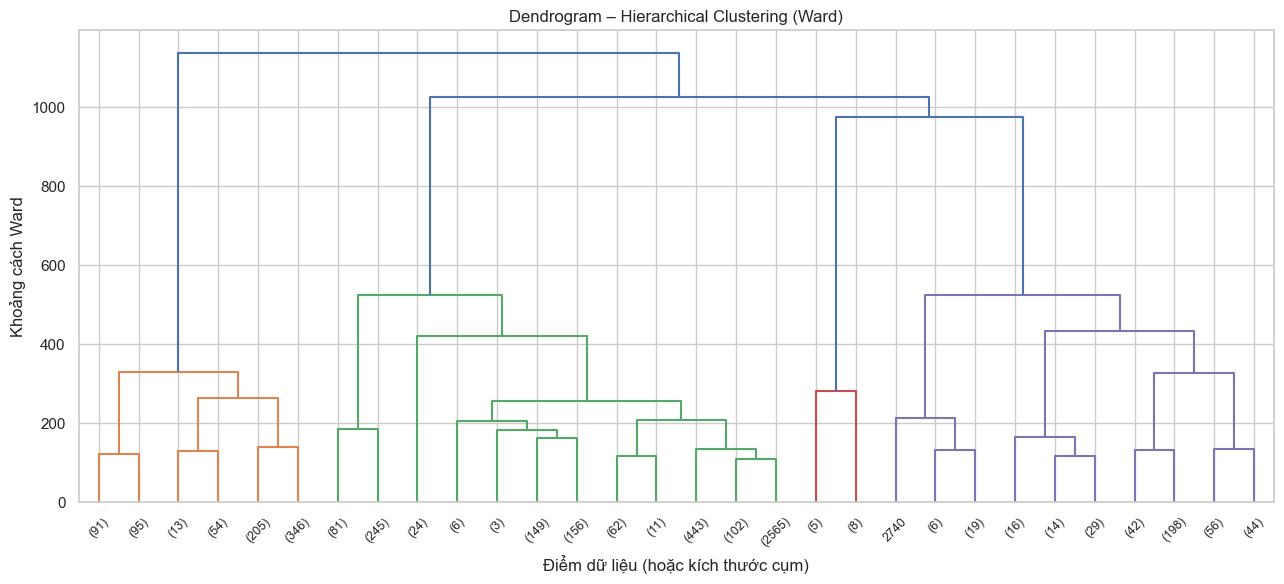

In [32]:
plt.figure(figsize=(13, 6))
sch.dendrogram(
    sch.linkage(X_model, method='ward'),
    truncate_mode='lastp', p=30,
    leaf_rotation=45, leaf_font_size=9
)
plt.title('Dendrogram – Hierarchical Clustering (Ward)')
plt.xlabel('Điểm dữ liệu (hoặc kích thước cụm)')
plt.ylabel('Khoảng cách Ward')
plt.tight_layout()
plt.show()


### 3b. Silhouette Score theo khoảng k tùy chọn

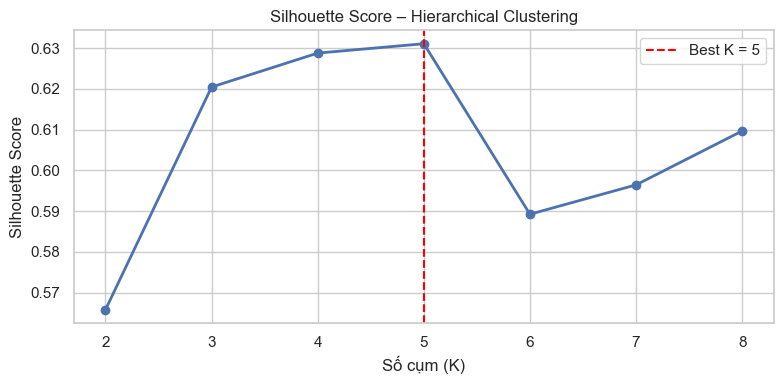

K tối ưu Hierarchical: 5


In [33]:
K_HC_RANGE = range(2, 9)   # ← điều chỉnh khoảng k tại đây

sil_hc = []
for k in K_HC_RANGE:
    labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_model)
    sil_hc.append(silhouette_score(X_model, labels))

best_k_hc = list(K_HC_RANGE)[int(np.argmax(sil_hc))]

plt.figure(figsize=(8, 4))
plt.plot(list(K_HC_RANGE), sil_hc, marker='o', linewidth=2)
plt.axvline(best_k_hc, color='red', linestyle='--', label=f'Best K = {best_k_hc}')
plt.xlabel('Số cụm (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score – Hierarchical Clustering')
plt.legend()
plt.tight_layout()
plt.show()
print(f"K tối ưu Hierarchical: {best_k_hc}")


### 3c. Fit Hierarchical với k tối ưu

In [34]:
K_HC    = best_k_hc        # ← ghi đè thủ công nếu muốn
hc_model = AgglomerativeClustering(n_clusters=K_HC, linkage='ward')
labels_hc = hc_model.fit_predict(X_model)
print(f"Hierarchical fitted với K = {K_HC}")


Hierarchical fitted với K = 5


## 4. DBSCAN – Grid Search tìm tham số tối ưu

### 4a. Grid Search (eps × min_samples) – tối đa hoá Silhouette Score

In [35]:
# ── Grid rộng để đảm bảo tìm được cấu hình hợp lệ ───────────────────────
eps_grid         = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 10.0]
min_samples_grid = [3, 5, 7, 9, 11, 15]
NOISE_RATIO_MAX  = 0.6   # ← cho phép tối đa 60% noise, tăng nếu cần

best_db_score  = -1
best_db_params = {}
records_db     = []

for eps, ms in product(eps_grid, min_samples_grid):
    labels  = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_model)
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    noise_ratio = n_noise / len(labels)

    if n_clust >= 2 and noise_ratio < NOISE_RATIO_MAX:
        score = silhouette_score(X_model, labels)
        records_db.append({
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clust, 'n_noise': n_noise,
            'noise_pct': round(noise_ratio * 100, 1),
            'silhouette': round(score, 4)
        })
        if score > best_db_score:
            best_db_score  = score
            best_db_params = {'eps': eps, 'min_samples': ms}

if not records_db:
    print("⚠️  Không tìm được cấu hình DBSCAN hợp lệ!")
    print("   → Thử tăng NOISE_RATIO_MAX hoặc mở rộng eps_grid / min_samples_grid")
    best_db_params = {'eps': eps_grid[len(eps_grid)//2],
                      'min_samples': min_samples_grid[0]}
else:
    df_db_grid = pd.DataFrame(records_db).sort_values('silhouette', ascending=False)
    print(df_db_grid.head(10).to_string(index=False))
    print(f"\nTham số tối ưu: eps={best_db_params['eps']}, "
          f"min_samples={best_db_params['min_samples']}, "
          f"Silhouette={best_db_score:.4f}")


 eps  min_samples  n_clusters  n_noise  noise_pct  silhouette
10.0            7           2      148        2.9      0.6923
10.0            9           2      166        3.3      0.6886
10.0           11           2      170        3.3      0.6874
10.0           15           2      184        3.6      0.6843
10.0            3           7       86        1.7      0.6808
 8.0            7           2      216        4.2      0.6736
 8.0           11           2      242        4.8      0.6713
 8.0            5           3      194        3.8      0.6629
 8.0           15           2      280        5.5      0.6608
10.0            5           4      118        2.3      0.6591

Tham số tối ưu: eps=10.0, min_samples=7, Silhouette=0.6923


### 4b. Fit DBSCAN với tham số tối ưu

In [36]:
dbscan    = DBSCAN(eps=best_db_params['eps'],
                   min_samples=best_db_params['min_samples'])
labels_db = dbscan.fit_predict(X_model)

n_clust = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = int(np.sum(labels_db == -1))
print(f"Số cụm: {n_clust} | Noise points: {n_noise}")


Số cụm: 2 | Noise points: 148


## 5. Spectral Clustering – Ma trận Silhouette Score

### 5a. Grid Search: k × sigma × k_nn  
`k_clusters` = 2–6 · `sigma` = [0.3, 0.5, 0.7, 1.0] · `k_nn` = [5, 10, 15]

In [37]:
# Tìm k_nn nhỏ nhất mà fully connected
import warnings
for k_nn in [10, 15, 20, 30, 50]:
    sc = SpectralClustering(n_clusters=3, affinity='nearest_neighbors',
                            n_neighbors=k_nn, random_state=42)
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        sc.fit_predict(X_model)
        connected = len(w) == 0
    print(f"k_nn={k_nn:3d} → {'✓ connected' if connected else '✗ not connected'}")

k_nn= 10 → ✗ not connected
k_nn= 15 → ✗ not connected
k_nn= 20 → ✗ not connected
k_nn= 30 → ✓ connected
k_nn= 50 → ✓ connected


In [38]:
#  dùng affinity='nearest_neighbors' (sparse) + subsample grid search.

import time

k_clusters_grid = range(2, 7)       # k = 2, 3, 4, 5, 6
k_nn_grid       = [40,42,45,47,50,55,60]   # số láng giềng cho nearest_neighbors affinity

# ── Subsample để grid search nhanh ───────────────────────────────────────
SUBSAMPLE_N = 5089    # ← tăng nếu dataset nhỏ hơn 2000; giảm nếu vẫn chậm
rng = np.random.default_rng(42)
idx_sub = rng.choice(len(X_model), size=min(SUBSAMPLE_N, len(X_model)), replace=False)
X_sub   = X_model[idx_sub]
print(f"Grid search trên {len(X_sub)} mẫu (/{len(X_model)} tổng)")

records_sc = []
t0 = time.time()

for k_nn in k_nn_grid:
    row = {'k_nn': k_nn}
    for k in k_clusters_grid:
        try:
            sc     = SpectralClustering(
                         n_clusters  = k,
                         affinity    = 'nearest_neighbors',  # sparse – nhanh hơn rbf rất nhiều
                         n_neighbors = k_nn,
                         n_jobs      = -1,                   # dùng toàn bộ CPU
                         random_state = 42,
                         n_init      = 10
                     )
            labels = sc.fit_predict(X_sub)
            score  = silhouette_score(X_sub, labels) if len(set(labels)) > 1 else np.nan
        except Exception as e:
            score = np.nan
        row[f'k={k}'] = round(float(score), 4) if (score is not None and score == score) else np.nan
    records_sc.append(row)
    elapsed = time.time() - t0
    print(f"  k_nn={k_nn:2d} xong — {elapsed:.1f}s")

df_spec_grid = pd.DataFrame(records_sc)
print("\n── Ma trận Silhouette Score ─────────────────────────────────────────")
print(df_spec_grid.to_string(index=False))

# ── Tìm tham số tốt nhất ─────────────────────────────────────────────────
k_cols   = [f'k={k}' for k in k_clusters_grid]
stacked  = df_spec_grid[k_cols].stack().dropna()
best_loc = stacked.idxmax()                     # (row_idx, 'k=X')
best_sc_row = df_spec_grid.loc[best_loc[0]]
best_sc_k   = int(best_loc[1].split('=')[1])
best_sc_knn = int(best_sc_row['k_nn'])
print(f"\nTốt nhất: k_nn={best_sc_knn}, k={best_sc_k}, "
      f"Silhouette={stacked[best_loc]:.4f}")
print(f"Tổng thời gian grid search: {time.time() - t0:.1f}s")


Grid search trên 5089 mẫu (/5089 tổng)
  k_nn=40 xong — 7.1s
  k_nn=42 xong — 15.0s
  k_nn=45 xong — 22.5s
  k_nn=47 xong — 29.8s
  k_nn=50 xong — 37.0s
  k_nn=55 xong — 44.5s
  k_nn=60 xong — 52.4s

── Ma trận Silhouette Score ─────────────────────────────────────────
 k_nn    k=2     k=3    k=4    k=5    k=6
   40 0.5643  0.4552 0.2280 0.2817 0.0802
   42 0.5640 -0.1532 0.2279 0.2798 0.0827
   45 0.5640 -0.1543 0.2275 0.2790 0.0875
   47 0.5640 -0.1543 0.2271 0.2798 0.0901
   50 0.5640 -0.1543 0.2264 0.2794 0.0937
   55 0.5640 -0.1543 0.2263 0.2769 0.0960
   60 0.5638 -0.1533 0.2234 0.2781 0.1044

Tốt nhất: k_nn=40, k=2, Silhouette=0.5643
Tổng thời gian grid search: 52.4s


In [39]:
K_SPECTRAL   = 5
KNN_SPECTRAL = 45

spectral = SpectralClustering(
    n_clusters   = K_SPECTRAL,
    affinity     = 'nearest_neighbors',
    n_neighbors  = KNN_SPECTRAL,
    random_state = 42,
    n_init       = 10,
    n_jobs       = -1
)
labels_spec = spectral.fit_predict(X_model)

### 5b. Fit Spectral với tham số tối ưu

## 6. Tổng kết – Silhouette · DBI · CHI

In [40]:
def evaluate(labels, name):
    mask   = labels != -1          # loại bỏ noise của DBSCAN
    X_eval = X_model[mask]
    l_eval = labels[mask]
    n_clust = len(set(l_eval))
    if n_clust < 2:
        return {'Algorithm': name, 'N_Clusters': n_clust,
                'Silhouette': np.nan, 'DBI': np.nan, 'CHI': np.nan}
    return {
        'Algorithm'  : name,
        'N_Clusters' : n_clust,
        'Silhouette' : round(silhouette_score(X_eval, l_eval), 4),
        'DBI'        : round(davies_bouldin_score(X_eval, l_eval), 4),
        'CHI'        : round(calinski_harabasz_score(X_eval, l_eval), 2),
    }

df_summary = pd.DataFrame([
    evaluate(labels_kmeans, 'K-Means'),
    evaluate(labels_hc,     'Hierarchical'),
    evaluate(labels_db,     'DBSCAN'),
    evaluate(labels_spec,   'Spectral'),
])
print(df_summary.to_string(index=False))


   Algorithm  N_Clusters  Silhouette    DBI     CHI
     K-Means           4      0.6343 0.6776 2719.68
Hierarchical           5      0.6311 0.7201 2371.16
      DBSCAN           2      0.7297 0.2548  278.88
    Spectral           5      0.2790 1.1042  987.91


## 7. Trực quan cụm – 2D (PCA)

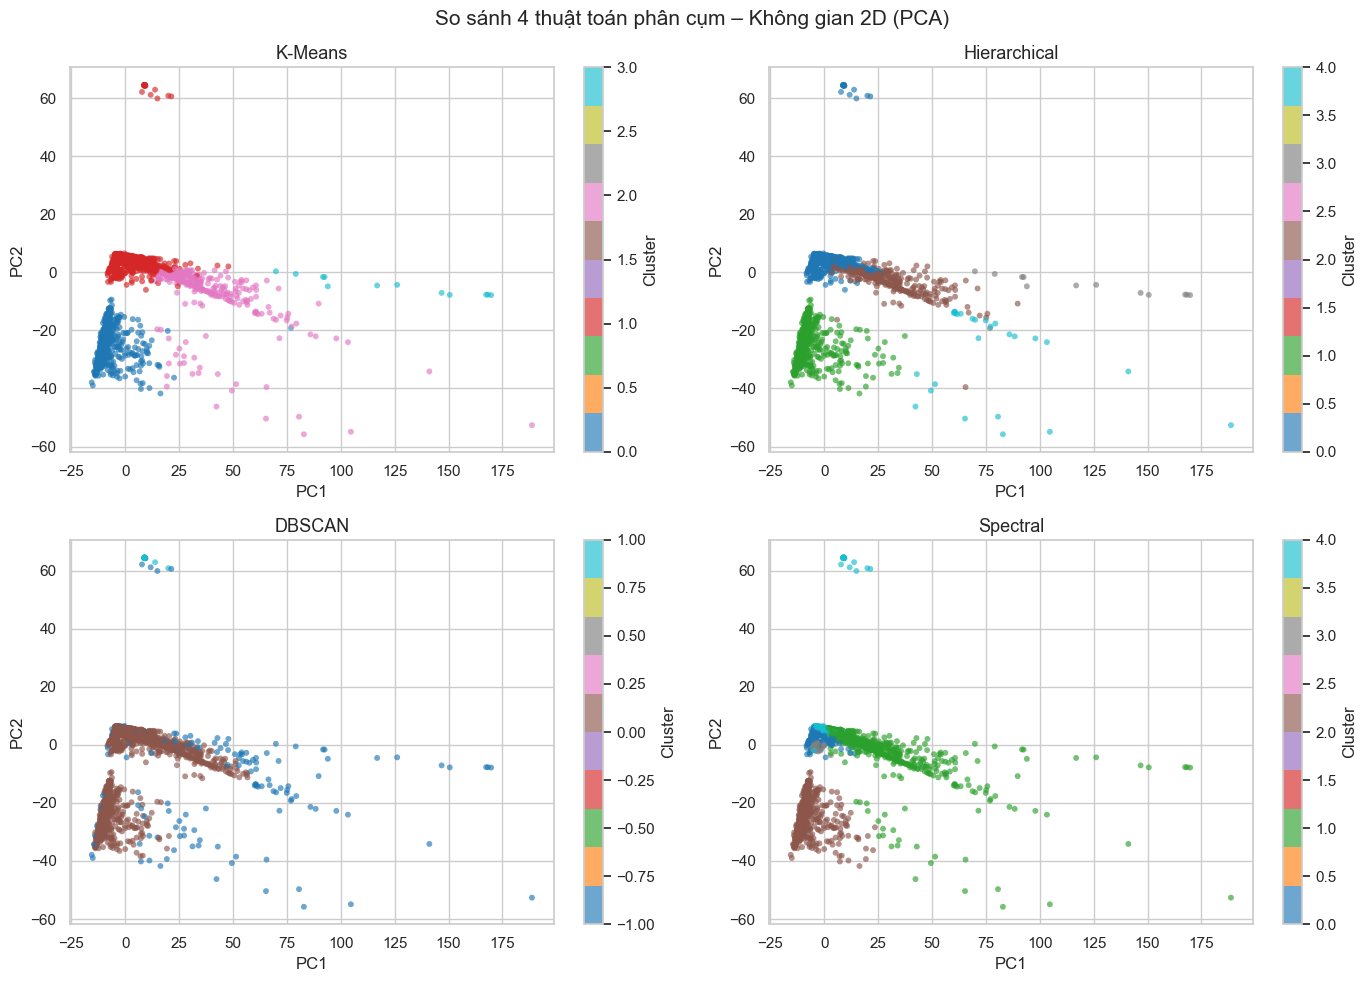

In [41]:
pca2d = PCA(n_components=2, random_state=42)
X_2d  = pca2d.fit_transform(X_model)

all_models = [
    ('K-Means',       labels_kmeans),
    ('Hierarchical',  labels_hc),
    ('DBSCAN',        labels_db),
    ('Spectral',      labels_spec),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, labels) in zip(axes.flat, all_models):
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                    c=labels, cmap='tab10', alpha=0.65, s=18, linewidths=0)
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(sc, ax=ax, label='Cluster')

plt.suptitle('So sánh 4 thuật toán phân cụm – Không gian 2D (PCA)', fontsize=15)
plt.tight_layout()
plt.show()


## 8. Trực quan cụm – 3D (Axes3D + PCA)

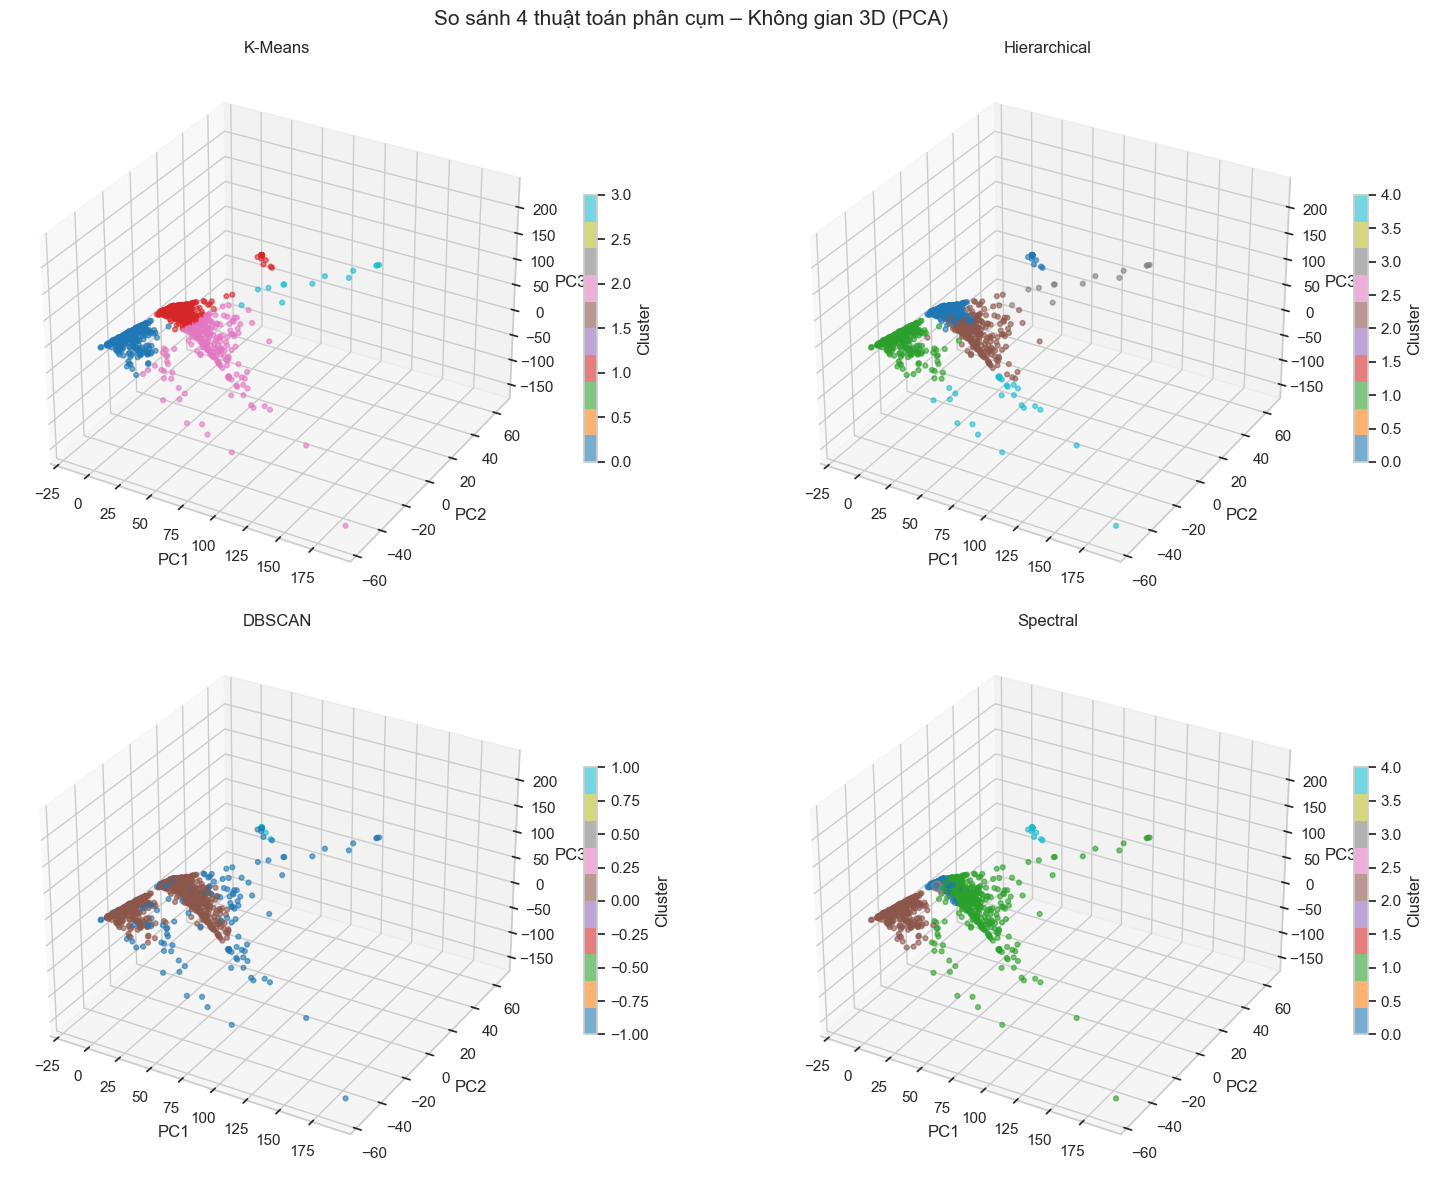

In [42]:
pca3d = PCA(n_components=3, random_state=42)
X_3d  = pca3d.fit_transform(X_model)

fig = plt.figure(figsize=(16, 12))
for i, (name, labels) in enumerate(all_models, 1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    sc = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
                    c=labels, cmap='tab10', alpha=0.6, s=12)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    fig.colorbar(sc, ax=ax, shrink=0.5, label='Cluster')

plt.suptitle('So sánh 4 thuật toán phân cụm – Không gian 3D (PCA)', fontsize=15)
plt.tight_layout()
plt.show()


## 9. DataFrame kết quả – cột `cluster_*` của từng model

In [43]:
df_clusters = df_raw.copy()
df_clusters['cluster_kmeans']       = labels_kmeans
df_clusters['cluster_hierarchical'] = labels_hc
df_clusters['cluster_dbscan']       = labels_db
df_clusters['cluster_spectral']     = labels_spec

cluster_cols = ['cluster_kmeans', 'cluster_hierarchical',
                'cluster_dbscan', 'cluster_spectral']

# Xem phân bố cụm từng model
for col in cluster_cols:
    print(f"\n{col}:")
    print(df_clusters[col].value_counts().sort_index().to_string())

df_clusters.head(10)



cluster_kmeans:
cluster_kmeans
0     788
1    3966
2     322
3      13

cluster_hierarchical:
cluster_hierarchical
0    3847
1     804
2     399
3      13
4      26

cluster_dbscan:
cluster_dbscan
-1     148
 0    4922
 1      19

cluster_spectral:
cluster_spectral
0     548
1     775
2     791
3      90
4    2885


,followerCnt,startingRate100k,recommendRate100k,followersGrowthRateRank,avgSixSecondsViewsRateRank,medianViewsRank,videoCompleteRateRank,engagementRateRank,avgSixSecondsViewsBenchMarkViews,medianBenchMarkViews,...,total_comments_recent,median_view_recent,max_view_recent,cov_view_recent,burstiness_recent,recency_days_recent,cluster_kmeans,cluster_hierarchical,cluster_dbscan,cluster_spectral
0,0.000000,-0.264363,-0.272189,0.000000,0.078531,8.472795,0.060136,-0.230721,18.211347,1.193833,...,0.315830,0.036979,-0.340029,0.956610,0.160784,-0.737646,1,2,0,1
1,0.827934,0.540219,0.220533,0.000000,0.000000,0.000000,0.000000,0.924174,0.000000,0.000000,...,2.573223,1.993098,1.848568,1.119467,-0.008681,0.102047,0,1,0,2
2,0.000000,-0.264363,-0.272189,2.564664,0.000000,1.852253,0.011523,-0.230721,5.606685,0.000000,...,0.439760,0.954022,-0.369363,0.511231,-0.414296,-0.170552,0,1,0,2
3,1.288772,1.003389,0.542573,0.000000,0.000000,0.000000,0.000000,0.736409,0.000000,0.000000,...,1.012554,0.873556,1.146435,1.555191,-0.355080,-0.726124,0,1,0,2
4,0.000000,-0.264363,2.761453,0.000000,0.000000,4.769334,0.024530,-0.230721,15.250072,0.000000,...,1.172850,1.450804,0.668147,0.771614,-0.054782,-0.202804,0,1,0,2
5,0.000000,-0.264363,-0.272189,35.786660,0.000000,0.691863,0.000000,-0.230721,0.771315,1.249887,...,0.752650,1.725535,1.051071,0.930961,0.060771,-0.156039,0,1,-1,2
6,0.000000,-0.264363,-0.272189,0.000000,0.108373,0.000000,0.049582,5.896537,8.517700,0.000000,...,1.683757,1.757402,1.682126,1.280589,0.025527,1.342817,1,0,0,4
7,0.000000,-0.264363,-0.272189,0.000000,0.002994,0.259378,0.002705,0.157333,0.000000,0.000000,...,1.966927,1.441907,1.624303,1.659759,-0.035939,-0.099856,1,0,0,4
8,1.177538,0.809794,0.440221,0.000000,0.000000,0.000000,0.000000,1.092890,0.000000,0.000000,...,1.365739,1.386826,1.344076,1.336509,-0.256221,-0.104187,1,0,0,4
9,0.000000,-0.264363,-0.272189,7.255448,0.028676,5.585111,0.000000,-0.230721,28.579295,0.685088,...,1.178826,1.672308,0.858894,0.915994,-0.075936,-0.538976,2,2,0,1


In [44]:
df_clusters.to_csv("cluster_done.csv", index=False)